<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB02 · El plato entero: entrenar una política de verdad

**Fase 0 · Lección 3 — Probar el plato entero**

Hasta ahora has visto las piezas por separado. Hoy las **conectas todas** y, por primera
vez, **entrenas** una política y ves cómo pasa de inútil a competente. Y lo mejor: lo harás
**aquí, en tu Pi**, con un robot pequeño, entendiendo cada pieza. Al final te llevarás el
mismo proceso a Colab con un humanoide de verdad.

> Vamos a usar un robot más simple que el humanoide: el **péndulo invertido**, un carrito con
> un palo encima que hay que mantener vertical. Es el "hola mundo" del control de robots y
> tiene exactamente las mismas piezas del mapa (robot, simulador, política, recompensa,
> entrenamiento). Cuando lo domines aquí, el humanoide es "lo mismo pero más grande".

## 1 · El problema y una idea nueva: el "retorno"

En el NB00 vimos que la recompensa es un número que puntúa **cada instante**. Pero para
juzgar una política entera necesitamos sumar todos esos instantes de un intento completo. A
esa suma se le llama **retorno**:

> **Retorno de un episodio** = la suma de todas las recompensas que el robot consigue desde
> que empieza hasta que se cae o se acaba el tiempo.

En el péndulo invertido la recompensa es sencilla: **+1 por cada paso de tiempo que el palo
sigue de pie**. Así que el retorno es, literalmente, **cuántos pasos aguanta**. Un episodio
dura como mucho 1000 pasos. Entrenar será **buscar la política que consigue el retorno más
alto**, es decir, que aguanta más tiempo.

Empecemos preparando el simulador y una función que mida el retorno.

In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"     # dibujar sin pantalla (como en el NB00)

import numpy as np
import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
from IPython.display import Image

# El entorno: carrito + palo. Observación de 4 números, acción de 1 número.
env = gym.make("InvertedPendulum-v5")
obs, _ = env.reset(seed=0)
print("Observación (qué percibe):", obs.shape, "->", np.round(obs, 3))
print("  [posición del carrito, ángulo del palo, velocidad del carrito, velocidad del palo]")
print("Acción (qué ordena):", env.action_space.shape,
      " un número: empujar el carrito a izquierda(-) o derecha(+)")

Observación (qué percibe): (4,) -> [ 0.003 -0.005 -0.009 -0.01 ]
  [posición del carrito, ángulo del palo, velocidad del carrito, velocidad del palo]
Acción (qué ordena): (1,)  un número: empujar el carrito a izquierda(-) o derecha(+)


In [2]:
def retorno(politica, semilla, entorno, pasos_max=1000):
    # Deja actuar a la política un episodio y devuelve el retorno (pasos que aguanta).
    obs, _ = entorno.reset(seed=int(semilla))
    total = 0.0
    for _ in range(pasos_max):
        accion = politica(obs)                       # la política decide
        obs, r, terminado, truncado, _ = entorno.step(accion)  # el simulador avanza
        total += r                                   # acumulamos la recompensa
        if terminado or truncado:                    # el palo se cayó o se acabó el tiempo
            break
    return total

print("Función 'retorno' lista.")

Función 'retorno' lista.


## 2 · La peor política: decidir al azar

Igual que en el NB00, empezamos con la política tonta (acciones al azar) para tener un punto
de partida contra el que comparar. Grabamos un GIF para verla.

In [3]:
def politica_azar(obs):
    return env.action_space.sample()          # ignora la observación, elige al azar

# Retorno medio de la política al azar sobre varias semillas
retornos_azar = [retorno(politica_azar, s, env) for s in range(5)]
print("Retornos al azar:", [int(x) for x in retornos_azar],
      "-> media", round(np.mean(retornos_azar), 1))

# GIF de la política al azar
env_vis = gym.make("InvertedPendulum-v5", render_mode="rgb_array")
env_vis.reset(seed=0)
frames = []
for _ in range(100):
    obs_v, _, term, trunc, _ = env_vis.step(env_vis.action_space.sample())
    frames.append(env_vis.render())
    if term or trunc:
        break
os.makedirs("assets", exist_ok=True)
imageio.mimsave("assets/nb02_azar.gif", frames, fps=25, loop=0)
print(f"Aguantó {len(frames)} pasos. GIF -> assets/nb02_azar.gif")

Retornos al azar: [3, 5, 3, 9, 2] -> media 4.4


Aguantó 3 pasos. GIF -> assets/nb02_azar.gif


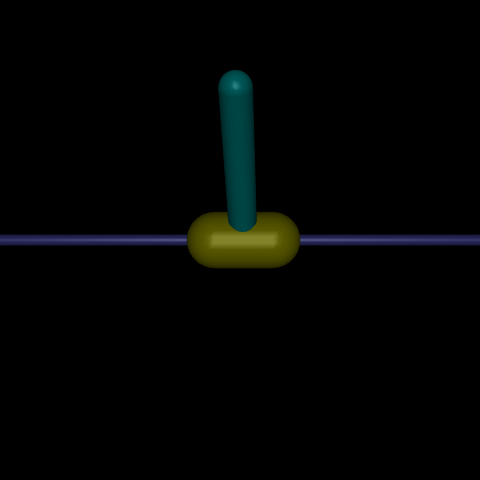

In [4]:
Image(filename="assets/nb02_azar.gif")

Se cae enseguida (retorno bajísimo). Ese es nuestro "antes". Ahora, la política que sí puede
aprender.

## 3 · La política más simple posible: una regla lineal

La política tiene que convertir la observación (4 números) en una acción (1 número). La
forma más simple de hacerlo es **multiplicar cada número de la observación por un peso y
sumarlo todo**:

```
   accion = w[0]*obs[0] + w[1]*obs[1] + w[2]*obs[2] + w[3]*obs[3]
```

Esos cuatro números `w` son los **pesos**: son la "personalidad" de la política. Cambiar los
pesos cambia cómo reacciona el robot. Esto es, de hecho, la red neuronal **más pequeña
posible** (sin capas ocultas): una simple combinación pesada de las entradas. En la Fase 2
las redes tendrán muchas más piezas, pero la idea de "entradas × pesos" es la misma.

> **Entrenar = encontrar los cuatro pesos `w` que hacen que el palo aguante más tiempo.**

En Python, "multiplicar cada entrada por su peso y sumar" se escribe con el operador `@`
(producto escalar): `w @ obs`.

In [5]:
def hace_politica(w):
    # Devuelve una política lineal con esos pesos w.
    def politica(obs):
        fuerza = w @ obs                         # w[0]*obs[0]+...+w[3]*obs[3]
        return np.clip([fuerza], -3.0, 3.0)      # el motor solo admite de -3 a 3
    return politica

# Una política con pesos al azar todavía no sabe nada:
w_inicial = np.zeros(4)                            # todos los pesos a cero
print("Retorno con pesos a cero:",
      int(retorno(hace_politica(w_inicial), 0, env)))

Retorno con pesos a cero: 23


## 4 · El entrenamiento: buscar los mejores pesos

¿Cómo encontramos los pesos buenos? Con el algoritmo de búsqueda más intuitivo que existe,
llamado **método de entropía cruzada** (CEM), que funciona así:

1. Genera un puñado de políticas candidatas (juegos de pesos) al azar alrededor de una
   "apuesta actual".
2. Prueba todas y quédate con las **mejores** (las "élite").
3. Mueve tu apuesta hacia el promedio de las élite y **estrecha** la búsqueda a su alrededor.
4. Repite. Poco a poco la búsqueda se concentra en la zona de pesos buenos.

Es como afinar una radio girando el dial hacia donde mejor se oye, cada vez con más cuidado.
Este método es un **primo sencillo** del algoritmo PPO que usaremos con el humanoide: ambos
son "prueba, mira qué va mejor, muévete hacia ahí", solo que PPO es mucho más eficiente. Para
el péndulo, CEM sobra.

Para juzgar cada candidata de forma justa medimos su retorno **promediando 3 semillas**
distintas (3 posiciones de partida), no una sola. Ya verás en la sección "lo que sale mal"
por qué esto importa.

In [6]:
rng = np.random.default_rng(0)     # generador de azar con semilla fija (reproducible)

mu = np.zeros(4)                   # apuesta actual (centro de la búsqueda)
sigma = np.ones(4)                 # cuánto exploramos alrededor (anchura)
poblacion, n_elite, iteraciones = 30, 6, 14

mejor_w, mejor_score = mu.copy(), -1.0
curva = []                         # guardaremos el mejor retorno de cada iteración

for it in range(iteraciones):
    candidatas = rng.normal(mu, sigma, size=(poblacion, 4))   # 30 juegos de pesos
    scores = np.array([
        np.mean([retorno(hace_politica(w), s, env) for s in range(3)])  # media de 3 semillas
        for w in candidatas
    ])
    elite = candidatas[np.argsort(scores)[-n_elite:]]         # los 6 mejores
    mu, sigma = elite.mean(axis=0), elite.std(axis=0) + 1e-3  # muévete y estrecha
    i_mejor = int(np.argmax(scores))
    if scores[i_mejor] > mejor_score:
        mejor_score, mejor_w = scores[i_mejor], candidatas[i_mejor]
    curva.append(mejor_score)
    print(f"iteración {it:2d}  mejor retorno medio: {mejor_score:6.1f}")

print("\nPesos aprendidos:", np.round(mejor_w, 2))

iteración  0  mejor retorno medio:  137.0


iteración  1  mejor retorno medio:  242.3


iteración  2  mejor retorno medio:  250.7


iteración  3  mejor retorno medio:  313.0


iteración  4  mejor retorno medio:  366.3


...

iteración  9  mejor retorno medio:  451.7


iteración 10  mejor retorno medio:  457.7


iteración 11  mejor retorno medio:  461.7


iteración 12  mejor retorno medio:  461.7


iteración 13  mejor retorno medio:  465.3

Pesos aprendidos: [-0.16  0.69  0.64  2.35]


Mira la columna de la derecha subir: de aguantar un par de pasos a aguantar cientos. Eso es
**aprendizaje**. Dibujémoslo — esta gráfica se llama **curva de aprendizaje** y la verás en
todos los entrenamientos del curso:

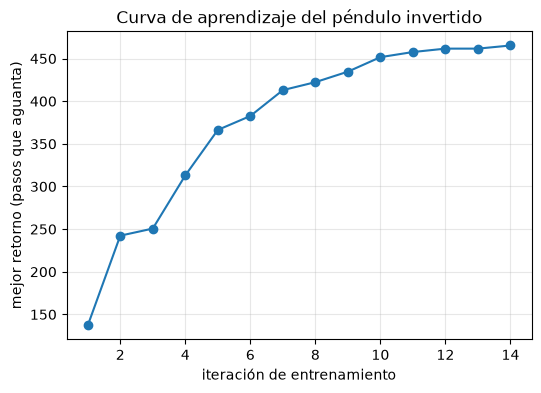

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(curva) + 1), curva, "o-")
plt.xlabel("iteración de entrenamiento")
plt.ylabel("mejor retorno (pasos que aguanta)")
plt.title("Curva de aprendizaje del péndulo invertido")
plt.grid(True, alpha=0.3)
plt.show()

## 5 · Ver la política entrenada

El momento bonito: grabemos al péndulo controlado por los pesos aprendidos y comparémoslo con
el "antes" al azar.

In [8]:
politica_entrenada = hace_politica(mejor_w)
env_vis.reset(seed=123)                       # una semilla que NO usamos al entrenar
obs_v, _ = env_vis.reset(seed=123)
frames = []
for _ in range(300):
    accion = politica_entrenada(obs_v)
    obs_v, r, term, trunc, _ = env_vis.step(accion)
    frames.append(env_vis.render())
    if term or trunc:
        break
imageio.mimsave("assets/nb02_entrenada.gif", frames, fps=25, loop=0)
print(f"La política entrenada aguantó {len(frames)} pasos (antes: unos pocos).")

La política entrenada aguantó 300 pasos (antes: unos pocos).


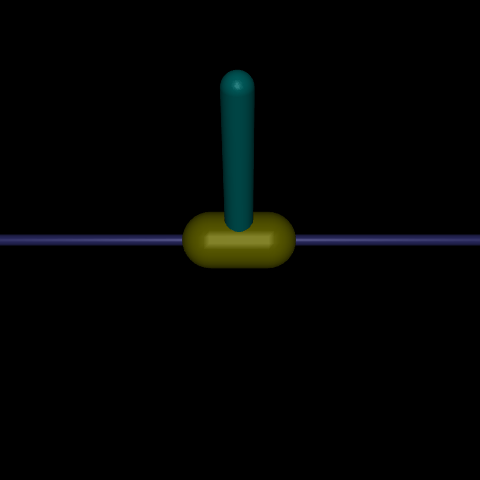

In [9]:
Image(filename="assets/nb02_entrenada.gif")

¡El palo se mantiene de pie! Has recorrido el **plato entero**: un robot en un simulador, una
política que decide, una recompensa que puntúa, y un entrenamiento que ha convertido pesos
inútiles en un controlador que funciona. Esta es, en miniatura, exactamente la misma historia
que la de un humanoide que aprende a andar.

## 6 · Lo que sale mal: juzgar por un solo intento

Aquí una trampa en la que caen hasta los profesionales. Tenemos una política entrenada.
¿Cómo de buena es? Es tentador lanzar **un** episodio, ver "aguantó 800 pasos" y declarar
victoria. Vamos a comprobar qué pasa si la evaluamos en **muchas** posiciones de partida
distintas.

In [10]:
retornos_finales = [retorno(politica_entrenada, s, env) for s in range(20, 40)]
retornos_finales = np.array(retornos_finales)
print("Retornos en 20 semillas nuevas:")
print(retornos_finales.astype(int))
print(f"\nmedia: {retornos_finales.mean():.0f}   "
      f"mínimo: {retornos_finales.min():.0f}   "
      f"máximo: {retornos_finales.max():.0f}")
print("\nSi solo hubieras mirado el mejor, dirías que es casi perfecta.")
print("Si solo hubieras mirado el peor, dirías que es mala. La VERDAD es la media.")

Retornos en 20 semillas nuevas:
[505 347 414 335 575 321 492 539 305 509 542 412 419 401 321 486 633 331
 500 409]

media: 440   mínimo: 305   máximo: 633

Si solo hubieras mirado el mejor, dirías que es casi perfecta.
Si solo hubieras mirado el peor, dirías que es mala. La VERDAD es la media.


Fíjate en la dispersión: el mismo controlador aguanta mucho en unas posiciones de partida y
menos en otras. Si hubieras juzgado por un único episodio (por suerte, el mejor o el peor),
te habrías engañado.

> **Regla que usaremos todo el curso:** una política se evalúa siempre sobre **muchos
> episodios con semillas nuevas** (que no se usaron al entrenar), y se mira la **media** (y la
> variación). Un solo número de un solo intento no significa casi nada. Fijar las **semillas**
> es lo que hace que estos experimentos sean **reproducibles**.

In [11]:
env.close(); env_vis.close()
print("Entornos cerrados.")

Entornos cerrados.


## 7 · ▶ En Colab: el mismo plato, con un humanoide de verdad

Lo que acabas de hacer con 4 pesos y un palo es, pieza por pieza, lo que hace el
entrenamiento de un humanoide. Las únicas diferencias:

| Aquí (tu Pi) | Con el humanoide (Colab, GPU) |
|---|---|
| Robot: carrito + palo (obs 4, acción 1) | Robot: Unitree G1 (obs y acciones por decenas) |
| Política: 4 pesos lineales | Política: **red neuronal** con miles de pesos |
| Entrenador: CEM (búsqueda simple) | Entrenador: **PPO** (mucho más eficiente) |
| Miles de episodios en 1 CPU, 30 s | **Millones** de pasos, miles de robots en paralelo, GPU |
| Retorno = pasos de pie | Recompensa = seguir una velocidad, seguir vivo, gastar poco… |

**Tu tarea ahora** (no corre en la Pi; necesita GPU):

1. Abre el notebook oficial de locomoción de MuJoCo Playground:
   <https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/locomotion.ipynb>
2. Arriba: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**.
3. Ejecuta las celdas de arriba abajo. La primera instala el software (equivale a lo que
   harías tú con `pip install playground`). El entorno del humanoide se llama
   `G1JoystickFlatTerrain` (el Unitree G1 sobre suelo plano).
4. Deja entrenar (si va lento en Colab gratis, reduce el número de pasos; entrenará peor pero
   verás la idea) y **reproduce el vídeo final**: un humanoide que anda.
5. Guarda el vídeo. Lo compararás en el NB03.

El esqueleto de lo que verás en ese notebook, para que reconozcas las piezas:

```python
# --- ESTO ES SOLO PARA COLAB CON GPU, NO SE EJECUTA EN LA PI ---
# pip install playground   (lo hace la primera celda del notebook oficial)
from mujoco_playground import registry, locomotion
from mujoco_playground.config import locomotion_params

env_name = "G1JoystickFlatTerrain"        # el humanoide Unitree G1
env = registry.load(env_name)             # (2) el simulador + (1) el robot
params = locomotion_params.brax_ppo_config(env_name)  # ajustes del entrenador PPO
# ...la celda de entrenamiento hace el bucle observar->política(red)->acción->recompensa
#    millones de veces con PPO en la GPU, y al final graba un vídeo del G1 andando.
```

No te preocupes por entender cada línea: aún no hemos estudiado redes (Fase 2) ni PPO (Fase
3). Ahora mismo solo queremos **verlo funcionar** y reconocer que es el mismo plato que
acabas de cocinar tú con el péndulo.

## 8 · Preguntas de comprensión

**P1.** ¿Qué es el **retorno** de un episodio y por qué en el péndulo invertido coincide con
"cuántos pasos aguanta"?

**P2.** La política lineal era `acción = w @ obs`. ¿Qué representan los cuatro números `w` y
qué significa "entrenar" en términos de esos números?

**P3.** Resume en tus palabras los cuatro pasos del método CEM.

**P4.** ¿Por qué evaluamos cada política candidata promediando varias semillas, y por qué al
final evaluamos en semillas **nuevas**?

**P5.** Une cada pieza del péndulo con su equivalente en el humanoide de Colab: (política
lineal), (CEM), (carrito+palo), (30 s en CPU).

<details>
<summary>▶ Solución P1</summary>

El retorno es la **suma de todas las recompensas** de un episodio, de principio a fin. En el
péndulo la recompensa es +1 por cada paso que el palo sigue vertical, así que sumar todas esas
recompensas equivale a contar los pasos que aguanta. Retorno alto = aguanta mucho.
</details>

<details>
<summary>▶ Solución P2</summary>

Los cuatro `w` son los **pesos**: cuánto influye cada número de la observación (posición,
ángulo, y sus velocidades) en la fuerza que se aplica al carrito. Son la "personalidad" de la
política. **Entrenar** es buscar los valores de esos cuatro números que hacen que el retorno
(los pasos de pie) sea lo más alto posible.
</details>

<details>
<summary>▶ Solución P3</summary>

(1) Generar varias políticas candidatas al azar alrededor de la apuesta actual. (2) Probarlas
todas y quedarse con las mejores (élite). (3) Mover la apuesta hacia el promedio de las élite y
estrechar la zona de búsqueda a su alrededor. (4) Repetir, de modo que la búsqueda se concentra
cada vez más en la zona de pesos buenos.
</details>

<details>
<summary>▶ Solución P4</summary>

Porque el retorno de **un** episodio depende mucho de la posición de partida (el azar): una
misma política puede parecer buenísima o mala según la semilla. Promediar varias da una medida
**justa** de cómo es de verdad. Y evaluamos al final en semillas **nuevas** para comprobar que
la política funciona en situaciones que no vio al entrenar, no solo en las que se "aprendió de
memoria". Es la diferencia entre saber y memorizar.
</details>

<details>
<summary>▶ Solución P5</summary>

- política lineal ↔ **red neuronal** del humanoide.
- CEM ↔ **PPO**.
- carrito + palo ↔ **Unitree G1** (el robot).
- 30 s en CPU ↔ **millones de pasos en GPU** (el entrenamiento).
</details>

## 9 · Posdata

Si te has perdido, dime el apartado y la frase exacta.

En el **NB03** —última lección de la Fase 0— tocarás la **recompensa**: cambiarás lo que el
robot considera "hacerlo bien", volverás a entrenar y verás cómo cambia su comportamiento…
incluyendo el fenómeno más divertido y peligroso de todo el campo: cuando el robot encuentra
una forma de **hacer trampa** para ganar recompensa sin hacer lo que queríamos.

---

## Apéndice · El Python de este notebook, desde cero

### A) Definir funciones: `def`
```python
def retorno(politica, semilla, entorno, pasos_max=1000):
    ...
    return total
```
`def` crea una función. Entre paréntesis van los **parámetros** (los datos que recibe).
`pasos_max=1000` es un parámetro con **valor por defecto**: si no lo pasas, vale 1000.
`return` indica qué devuelve.

### B) Funciones que devuelven funciones (fábricas)
```python
def hace_politica(w):
    def politica(obs):
        return np.clip([w @ obs], -3, 3)
    return politica
```
`hace_politica` **fabrica** una política a medida de unos pesos `w` y la devuelve. La función
interna `politica` "recuerda" el `w` con el que se creó. Es un patrón muy útil: cada juego de
pesos produce su propia política.

### C) El producto escalar `@`
`w @ obs` multiplica cada elemento de `w` por el de `obs` en la misma posición y **suma todo**:
`w[0]*obs[0] + w[1]*obs[1] + ...`. Es "combinar entradas con pesos", la operación básica de
toda red neuronal.

### D) `np.clip(x, min, max)` — recortar
Devuelve `x` pero sin salirse del rango: si es menor que `min` lo sube a `min`, si es mayor que
`max` lo baja a `max`. Aquí, porque el motor solo admite fuerzas entre −3 y 3.

### E) `np.random.default_rng(0)` y `rng.normal(...)`
`default_rng(0)` crea un **generador de números al azar** con semilla 0 (reproducible: mismo
resultado cada vez). `rng.normal(mu, sigma, size=(30,4))` saca 30×4 números al azar siguiendo
una campana de Gauss centrada en `mu` y de anchura `sigma`.

### F) `np.argsort` y quedarse con los mejores
`np.argsort(scores)` da las **posiciones** que ordenarían el array de menor a mayor.
`[-6:]` toma los seis últimos (los de mayor puntuación). Así `candidatas[np.argsort(scores)[-6:]]`
son las seis mejores candidatas.

### G) `.mean(axis=0)` y `.std(axis=0)`
Sobre una tabla de 6 filas × 4 columnas, `axis=0` opera **por columnas**: da la media (y la
desviación) de cada uno de los 4 pesos por separado. Así calculamos el centro y la anchura de
la nueva búsqueda.

### H) Comprensiones anidadas
```python
scores = np.array([ np.mean([retorno(...) for s in range(3)]) for w in candidatas ])
```
La de dentro calcula el retorno en 3 semillas y lo promedia; la de fuera repite eso para cada
candidata. Resultado: un array con la puntuación de cada candidata.

### I) `.astype(int)`
Convierte los números de un array a enteros (quita los decimales), solo para imprimir más
limpio.